LINK TO DATASET - https://huggingface.co/datasets/Mosab-Rezaei/19th-century-novelists/tree/main

## Imports

In [1]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col,
    sum as spark_sum,
    trim,
    count,
    round,
    skewness,
    avg,
    row_number,
    rand
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping

import re

np.random.seed(42)
tf.random.set_seed(42)

## STEP 1 - Dataset Loading and Suitability

In [2]:
spark = SparkSession.builder \
    .appName("Authors Assignment") \
    .master("local[*]") \
    .getOrCreate()

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/23 20:28:43 WARN Utils: Your hostname, Davayan-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.68.107 instead (on interface en0)
26/09/23 20:28:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/23 20:28:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0


In [3]:
# Load the CSV correctly.
# multiLine=True is required because some text fields contain line breaks.

authors_df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("multiLine", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv("Dataset%20-%20Five%20Authors%20.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
print("Number of rows:", authors_df.count())
print("Number of columns:", len(authors_df.columns))

authors_df.select("Sentence", "Author").show(5, truncate=False)

Number of rows: 115471
Number of columns: 45
+--------------------------------------------------------------------------------------------------------------------------------------+---------------+
|Sentence                                                                                                                              |Author         |
+--------------------------------------------------------------------------------------------------------------------------------------+---------------+
|Why, I have been ashamed of your moroseness there!                                                                                    |Charles Dickens|
|From the blacksmith’s.” “Halloa!” said the sergeant, staring at Joe.                                                                  |Charles Dickens|
|Their conversations, however, were not always on subjects so high as history or morals.                                               |Jane Austen    |
|Thus, you were to hammer boys round—

In [5]:
authors_df.printSchema()

root
 |-- Sentence: string (nullable = true)
 |-- Charles Dickens: integer (nullable = true)
 |-- Jane Austen: integer (nullable = true)
 |-- Mark Twain: integer (nullable = true)
 |-- Louisa May Alcott: integer (nullable = true)
 |-- Herman Melville: integer (nullable = true)
 |-- Author: string (nullable = true)
 |-- Label_(number): integer (nullable = true)
 |-- Label_(tuple): string (nullable = true)
 |-- Merged: string (nullable = true)
 |-- num_words: double (nullable = true)
 |-- pos: string (nullable = true)
 |-- parse_tree: string (nullable = true)
 |-- dependency: string (nullable = true)
 |-- verb_count: double (nullable = true)
 |-- adverb_count: double (nullable = true)
 |-- noun_count: double (nullable = true)
 |-- coord_count: double (nullable = true)
 |-- subord_count: double (nullable = true)
 |-- verb_percent: double (nullable = true)
 |-- adverb_percent: double (nullable = true)
 |-- noun_percent: double (nullable = true)
 |-- coord_percent: double (nullable = true)


The dataset was loaded using PySpark to confirm its structure and suitability for text classification. 
The dataset has 115,471 records and 45 columns. The modelling task uses the raw sentence text as the predictor and the author name as the target.

In [6]:
# Count the number of records for each author
author_counts = authors_df.groupBy("Author").count().orderBy("count", ascending=False)

author_counts.show(truncate=False)

+-----------------+-----+
|Author           |count|
+-----------------+-----+
|Charles Dickens  |26856|
|Mark Twain       |25527|
|Herman Melville  |24011|
|Jane Austen      |20044|
|Louisa May Alcott|19033|
+-----------------+-----+



## STEP 2 - Exploratory Data Analysis

## 2.1 Missing Values and Duplicates

In [7]:
# Check for missing values in the main modelling columns
authors_df.select(
    spark_sum(col("Sentence").isNull().cast("int")).alias("Missing_Sentences"),
    spark_sum(col("Author").isNull().cast("int")).alias("Missing_Authors")
).show()

+-----------------+---------------+
|Missing_Sentences|Missing_Authors|
+-----------------+---------------+
|                0|              0|
+-----------------+---------------+



In [8]:
# Count empty or whitespace-only sentences
blank_sentences = authors_df.filter(
    col("Sentence").isNotNull() &
    (trim(col("Sentence")) == "")
).count()

print("Blank sentences:", blank_sentences)

Blank sentences: 0


In [9]:
# Count exact duplicate Sentence-Author combinations
duplicate_count = authors_df.count() - \
    authors_df.select("Sentence", "Author").dropDuplicates().count()

print("Duplicate Sentence-Author records:", duplicate_count)

Duplicate Sentence-Author records: 41


In [10]:
# Keep valid records and remove duplicate Sentence-Author combinations

clean_df = authors_df \
    .filter(col("Sentence").isNotNull()) \
    .filter(col("Author").isNotNull()) \
    .filter(trim(col("Sentence")) != "") \
    .dropDuplicates(["Sentence", "Author"])

clean_count = clean_df.count()

print("Original number of records:", authors_df.count())
print("Cleaned number of records:", clean_count)
print("Records removed:", authors_df.count() - clean_count)

Original number of records: 115471
Cleaned number of records: 115430


Records removed: 41


No missing or blank values were found in the Sentence or Author columns. 
However, 41 duplicate Sentence-Author pairs were identified and removed before further analysis. 
This reduced the dataset from 115,471 to 115,430 clean records and reduced the risk of identical text appearing in both training and testing data.

## 2.2 - Class Distribution

In [11]:
# Check the class distribution after cleaning

clean_author_counts = clean_df.groupBy("Author") \
    .count() \
    .orderBy("count", ascending=False)

clean_author_counts.show(truncate=False)

+-----------------+-----+
|Author           |count|
+-----------------+-----+
|Charles Dickens  |26849|
|Mark Twain       |25515|
|Herman Melville  |23998|
|Jane Austen      |20036|
|Louisa May Alcott|19032|
+-----------------+-----+



In [12]:
# Total number of cleaned records
total_records = clean_df.count()

# Calculate the number and percentage of records for each author
author_distribution = clean_df.groupBy("Author") \
    .agg(count("*").alias("Count")) \
    .withColumn(
        "Percentage",
        round((col("Count") / total_records) * 100, 2)
    ) \
    .orderBy("Count", ascending=False)

author_distribution.show(truncate=False)

+-----------------+-----+----------+
|Author           |Count|Percentage|
+-----------------+-----+----------+
|Charles Dickens  |26849|23.26     |
|Mark Twain       |25515|22.1      |
|Herman Melville  |23998|20.79     |
|Jane Austen      |20036|17.36     |
|Louisa May Alcott|19032|16.49     |
+-----------------+-----+----------+



/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


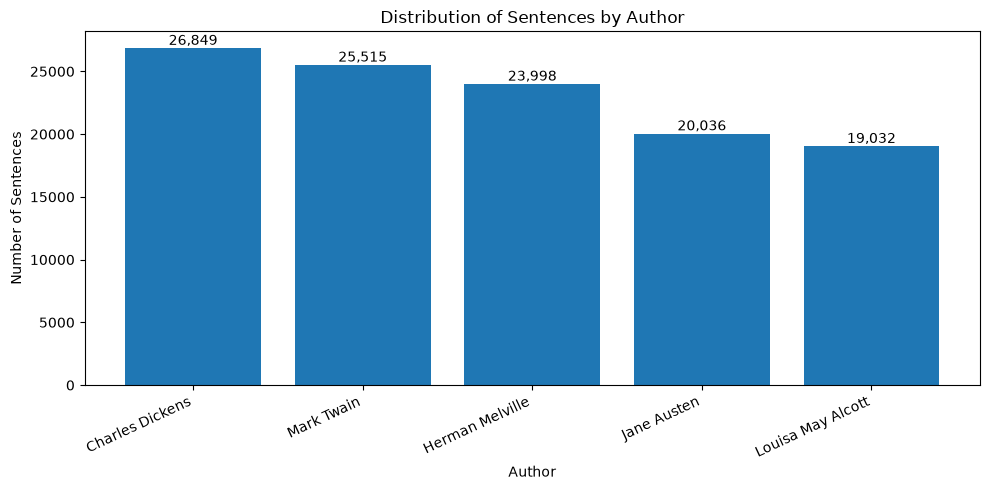

In [13]:
# Convert only the small aggregated result to Pandas for visualisation
author_distribution_pd = author_distribution.toPandas()

# Create the bar chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    author_distribution_pd["Author"],
    author_distribution_pd["Count"]
)

plt.title("Distribution of Sentences by Author")
plt.xlabel("Author")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=25, ha="right")

# Display the count above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Charles Dickens had the largest number of sentences, while Louisa May Alcott had the fewest. 
The imbalance was moderate rather than severe

## STEP 2.3 - Sentence Length 

In [14]:
# Summary statistics for sentence length
clean_df.select("num_words").describe().show()

+-------+------------------+
|summary|         num_words|
+-------+------------------+
|  count|            115430|
|   mean|22.675872823356148|
| stddev|12.603109844574213|
|    min|               1.0|
|    max|              83.0|
+-------+------------------+



In [15]:
# Calculate sentence length percentiles
percentiles = clean_df.approxQuantile(
    "num_words",
    [0.25, 0.50, 0.75],
    0.001
)

print("25th percentile:", percentiles[0])
print("Median :", percentiles[1])
print("75th percentile:", percentiles[2])


25th percentile: 12.0
Median : 20.0
75th percentile: 31.0


In [16]:
# Measure skewness of sentence lengths
clean_df.select(
    skewness("num_words").alias("Sentence_Length_Skewness")
).show()

+------------------------+
|Sentence_Length_Skewness|
+------------------------+
|       0.597293619260551|
+------------------------+



/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


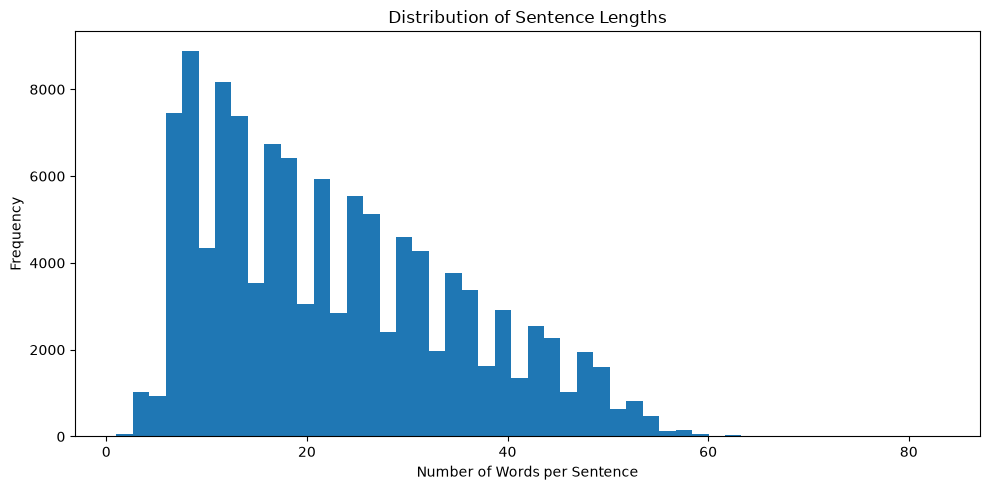

In [17]:
# Convert only the sentence length column to Pandas for visualisation
word_length_pd = clean_df.select("num_words").toPandas()

plt.figure(figsize=(10, 5))

plt.hist(
    word_length_pd["num_words"],
    bins=50
)

plt.title("Distribution of Sentence Lengths")
plt.xlabel("Number of Words per Sentence")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [20]:
# Average sentence length for each author
author_length_stats = clean_df.groupBy("Author").agg(
    round(avg("num_words"), 2).alias("Average_Words")
).orderBy("Average_Words", ascending=False)

author_length_stats.show(truncate=False)

+-----------------+-------------+
|Author           |Average_Words|
+-----------------+-------------+
|Louisa May Alcott|24.91        |
|Herman Melville  |24.42        |
|Mark Twain       |22.0         |
|Charles Dickens  |21.41        |
|Jane Austen      |21.03        |
+-----------------+-------------+



In [21]:
author_length_pd = author_length_stats.toPandas()

/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


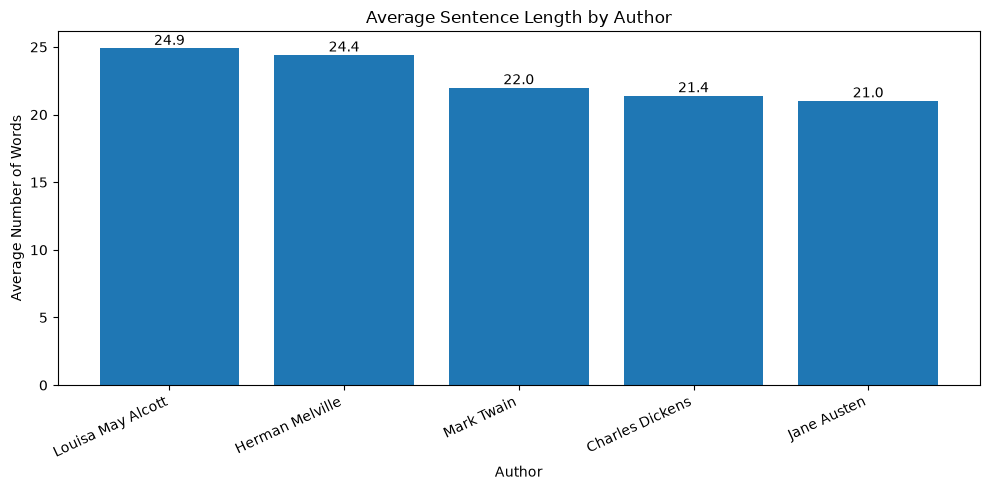

In [22]:
# Convert the small aggregated table to Pandas
author_length_pd = author_length_stats.toPandas()

plt.figure(figsize=(10, 5))

bars = plt.bar(
    author_length_pd["Author"],
    author_length_pd["Average_Words"]
)

plt.title("Average Sentence Length by Author")
plt.xlabel("Author")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Sentence length was analysed because it affects tokenisation and padding. The cleaned dataset had an average sentence length of approximately 22.68 words, with values ranging from 1 to 83 words. The distribution was slightly positively skewed, showing that most sentences were moderate in length with a smaller number of longer sentences.

## 2.4 - Outliers

In [23]:
# Calculate quartiles for sentence length
quartiles = clean_df.approxQuantile(
    "num_words",
    [0.25, 0.75],
    0.001
)

q1 = quartiles[0]
q3 = quartiles[1]

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 12.0
Q3: 31.0
IQR: 19.0
Lower bound: -16.5
Upper bound: 59.5


In [24]:
# Count records outside the IQR boundaries
short_sentence_count = clean_df.filter(
    col("num_words") < lower_bound
).count()

long_sentence_count = clean_df.filter(
    col("num_words") > upper_bound
).count()

print("Sentences below lower bound:", short_sentence_count)
print("Sentences above upper bound:", long_sentence_count)

Sentences below lower bound: 0
Sentences above upper bound: 98


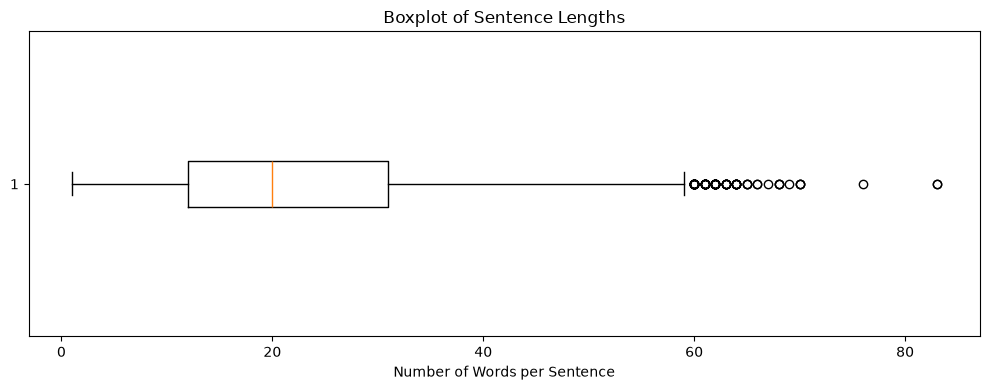

In [25]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    word_length_pd["num_words"],
    orientation="horizontal"
)

plt.title("Boxplot of Sentence Lengths")
plt.xlabel("Number of Words per Sentence")

plt.tight_layout()
plt.show()

In [26]:
# Inspect the longest sentences in the dataset
clean_df.select(
    "Author",
    "num_words",
    "Sentence"
).orderBy(
    col("num_words").desc()
).show(10, truncate=False)

+---------------+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Author         |num_words|Sentence                                                                                                                                                                                                                                                                                                                               |
+---------------+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [27]:
# Percentage of each author's sentences that exceed the upper IQR boundary
author_total = clean_df.groupBy("Author") \
    .agg(count("*").alias("Total"))

author_long = clean_df \
    .filter(col("num_words") > upper_bound) \
    .groupBy("Author") \
    .agg(count("*").alias("Long_Sentences"))

long_sentence_rates = author_total.join(
    author_long,
    on="Author",
    how="left"
).fillna(0)

long_sentence_rates = long_sentence_rates.withColumn(
    "Long_Sentence_Percentage",
    round(
        col("Long_Sentences") / col("Total") * 100,
        2
    )
)

long_sentence_rates.orderBy(
    "Long_Sentence_Percentage",
    ascending=False
).show(truncate=False)

+-----------------+-----+--------------+------------------------+
|Author           |Total|Long_Sentences|Long_Sentence_Percentage|
+-----------------+-----+--------------+------------------------+
|Herman Melville  |23998|50            |0.21                    |
|Mark Twain       |25515|19            |0.07                    |
|Charles Dickens  |26849|20            |0.07                    |
|Louisa May Alcott|19032|5             |0.03                    |
|Jane Austen      |20036|4             |0.02                    |
+-----------------+-----+--------------+------------------------+



## 2.5 - Linguistic Patterns

In [28]:
# Display the data type of each column
for column, dtype in clean_df.dtypes:
    print(f"{column}: {dtype}")

Sentence: string
Charles Dickens: int
Jane Austen: int
Mark Twain: int
Louisa May Alcott: int
Herman Melville: int
Author: string
Label_(number): int
Label_(tuple): string
Merged: string
num_words: double
pos: string
parse_tree: string
dependency: string
verb_count: double
adverb_count: double
noun_count: double
coord_count: double
subord_count: double
verb_percent: double
adverb_percent: double
noun_percent: double
coord_percent: double
subord_percent: double
longest_path_parstree: int
depth_parstree: int
longest_word_length: int
questions: int
questions_wh: int
PRP_first: int
PRP_second: int
PRP_third: int
PRP_first_percent: double
PRP_second_percent: double
PRP_third_percent: double
noun_phrase: int
Passive: string
Compare_Super: string
CONJP: boolean
Imperative: boolean
Nsubj: double
PP_Percent: double
PP_VP_Percent: double
PP_NP_Percent: double
PP_O_Percent: double


In [29]:
# Linguistic features selected for comparison
linguistic_features = [
    "verb_percent",
    "adverb_percent",
    "noun_percent",
    "coord_percent",
    "subord_percent",
    "PRP_first_percent",
    "PRP_second_percent",
    "PRP_third_percent",
    "PP_Percent",
    "noun_phrase",
    "Nsubj"
]

In [30]:
# Calculate average linguistic feature values for each author
author_feature_means = clean_df.groupBy("Author").agg(
    *[
        round(avg(feature), 3).alias(feature)
        for feature in linguistic_features
    ]
)

author_feature_means.show(truncate=False)

+-----------------+------------+--------------+------------+-------------+--------------+-----------------+------------------+-----------------+----------+-----------+-----+
|Author           |verb_percent|adverb_percent|noun_percent|coord_percent|subord_percent|PRP_first_percent|PRP_second_percent|PRP_third_percent|PP_Percent|noun_phrase|Nsubj|
+-----------------+------------+--------------+------------+-------------+--------------+-----------------+------------------+-----------------+----------+-----------+-----+
|Mark Twain       |0.158       |0.061         |0.183       |0.041        |0.095         |0.023            |0.007             |0.035            |0.276     |6.944      |1.326|
|Herman Melville  |0.14        |0.061         |0.19        |0.032        |0.106         |0.014            |0.007             |0.022            |0.324     |7.663      |1.308|
|Charles Dickens  |0.156       |0.057         |0.153       |0.031        |0.091         |0.029            |0.014             |0.03

In [31]:
percentage_features = [
    "verb_percent",
    "adverb_percent",
    "noun_percent",
    "coord_percent",
    "subord_percent"
]

In [32]:
# Convert the aggregated author statistics to Pandas
feature_means_pd = author_feature_means.select(
    "Author",
    *percentage_features
).toPandas()

/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


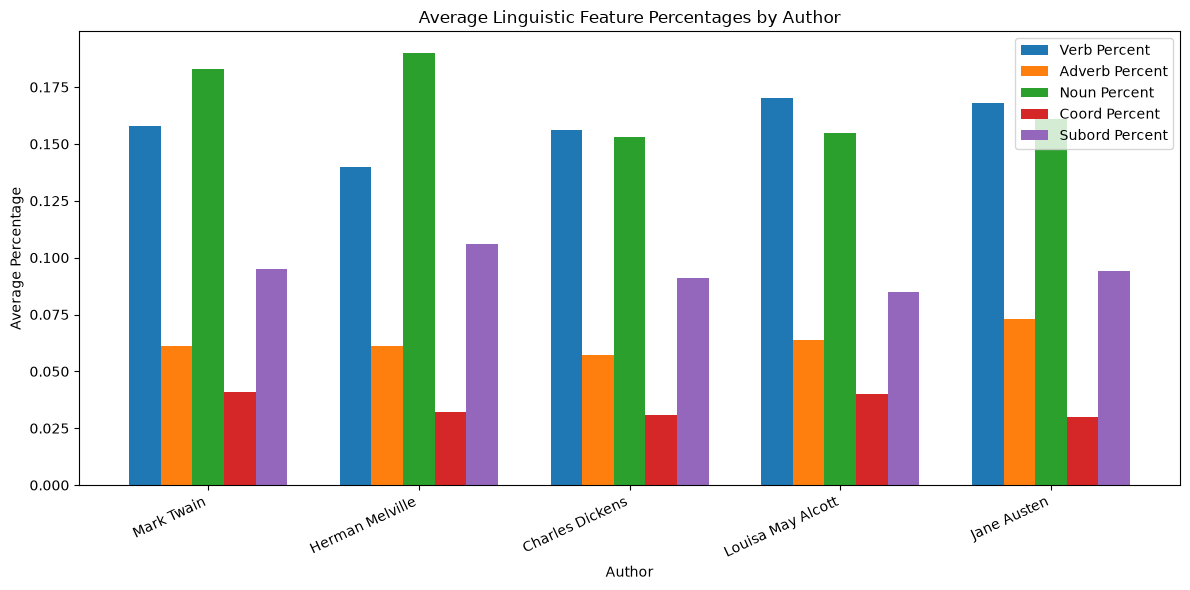

In [33]:
authors = feature_means_pd["Author"]
x = np.arange(len(authors))
width = 0.15

plt.figure(figsize=(12, 6))

for i, feature in enumerate(percentage_features):
    plt.bar(
        x + i * width,
        feature_means_pd[feature],
        width,
        label=feature.replace("_", " ").title()
    )

plt.title("Average Linguistic Feature Percentages by Author")
plt.xlabel("Author")
plt.ylabel("Average Percentage")
plt.xticks(
    x + width * 2,
    authors,
    rotation=25,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

The linguistic features were used for exploratory analysis only. They helped identify measurable differences in writing style between authors, but they were not used as direct inputs to the LSTM model.

## STEP 3 - Feature Selection

The original dataset contains many engineered linguistic and label related columns. 
For the LSTM model, only the raw sentence text is used as the predictor and Author is used as the target.

Columns that directly encode the author label are excluded to prevent target leakage. 
The engineered linguistic features are retained only for EDA and are not used as direct model inputs.

In [34]:
# Columns excluded because they directly encode the target author
leakage_columns = [
    "Charles Dickens",
    "Jane Austen",
    "Mark Twain",
    "Louisa May Alcott",
    "Herman Melville",
    "Label_(number)",
    "Label_(tuple)",
    "Merged"
]

print("Columns excluded due to target leakage:")

for column in leakage_columns:
    print("-", column)

Columns excluded due to target leakage:
- Charles Dickens
- Jane Austen
- Mark Twain
- Louisa May Alcott
- Herman Melville
- Label_(number)
- Label_(tuple)
- Merged


In [35]:
# Keep only the variables required for the LSTM model
model_df = clean_df.select(
    "Sentence",
    "Author"
)

model_df.show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+
|Sentence                                                                                                                                                                                                                                 |Author         |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+
|“D’ye hear there, fore and aft?                                                                                                                                                                                                          |Herman Me

The final modelling dataset therefore contains only Sentence and Author. 
This keeps the model focused on learning sequential patterns from the text itself while avoiding target leakage.

## STEP 4 - Text Preprocessing and Modelling Dataset

In [36]:
# Number of sentences to retain for each author
SAMPLES_PER_AUTHOR = 10000

# Randomly number records within each author
window_spec = Window.partitionBy("Author").orderBy(rand(seed=42))

balanced_df = model_df.withColumn(
    "row_number",
    row_number().over(window_spec)
).filter(
    col("row_number") <= SAMPLES_PER_AUTHOR
).drop("row_number")

In [37]:
balanced_df.groupBy("Author").count().orderBy("Author").show()
print("Balanced dataset size:", balanced_df.count())

+-----------------+-----+
|           Author|count|
+-----------------+-----+
|  Charles Dickens|10000|
|  Herman Melville|10000|
|      Jane Austen|10000|
|Louisa May Alcott|10000|
|       Mark Twain|10000|
+-----------------+-----+



Balanced dataset size: 50000


/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


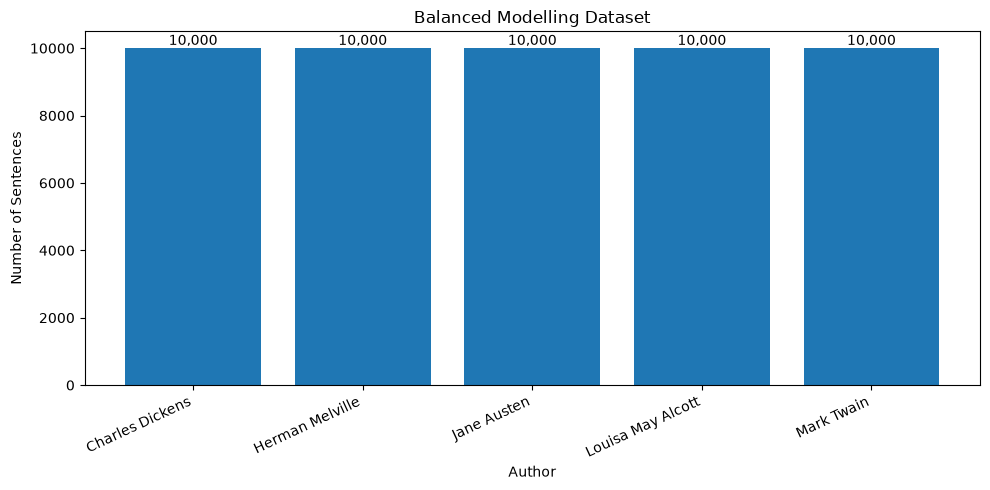

In [38]:
balanced_counts_pd = balanced_df.groupBy("Author") \
    .count() \
    .orderBy("Author") \
    .toPandas()

plt.figure(figsize=(10, 5))

bars = plt.bar(
    balanced_counts_pd["Author"],
    balanced_counts_pd["count"]
)

plt.title("Balanced Modelling Dataset")
plt.xlabel("Author")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [39]:
# Convert text to lowercase
prepared_df = balanced_df.withColumn(
    "Cleantext",
    F.lower(F.col("Sentence"))
)

# Remove punctuation and special characters
prepared_df = prepared_df.withColumn(
    "Cleantext",
    F.regexp_replace(
        F.col("Cleantext"),
        "[^a-zA-Z0-9\\s]",
        ""
    )
)

model_pd = prepared_df.select(
    "Sentence",
    "Author",
    "Cleantext"
).toPandas()

/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/_davayan/Library/Python/3.12/lib/python/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


The sentence text was converted to lowercase and punctuation and special characters were removed. 
Stopwords were retained so that common function words could still contribute to writing-style patterns.

In [40]:
label_encoder = LabelEncoder()

model_pd["Author_Label"] = label_encoder.fit_transform(
    model_pd["Author"]
)

X = model_pd["Cleantext"]
y = model_pd["Author_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 40000
Test size: 10000


In [41]:
print("Training class counts:")
print(y_train.value_counts().sort_index())

print("\nTest class counts:")
print(y_test.value_counts().sort_index())

Training class counts:
Author_Label
0    8000
1    8000
2    8000
3    8000
4    8000
Name: count, dtype: int64

Test class counts:
Author_Label
0    2000
1    2000
2    2000
3    2000
4    2000
Name: count, dtype: int64


In [42]:
VOCAB_SIZE = 5000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Unique words found:", len(tokenizer.word_index))
print("Vocabulary size used:", VOCAB_SIZE)

Unique words found: 35387
Vocabulary size used: 5000


In [43]:
# Convert text into integer sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

print("Example original sentence:")
print(X_train.iloc[0])

print("Example encoded sequence:")
print(train_sequences[0])


Example original sentence:
there a barelegged shepherd in wooden shoes pointed hat and rough jacket over one shoulder sat piping on a stone while his goats skipped among the rocks or lay at his feet
Example encoded sequence:
[42, 6, 1, 1, 8, 2193, 2415, 1341, 632, 3, 1528, 1529, 101, 39, 1007, 247, 1, 27, 6, 873, 140, 14, 1, 4681, 239, 2, 1960, 52, 316, 25, 14, 346]


In [44]:
# Calculate the length of each tokenised training sentence
sequence_lengths = np.array([
    len(sequence) for sequence in train_sequences
])

print("Minimum sequence length:", sequence_lengths.min())
print("Average sequence length:", np.round(sequence_lengths.mean(), 2))
print("Median sequence length:", np.median(sequence_lengths))
print("Maximum sequence length:", sequence_lengths.max())

print("\n90th percentile:", np.percentile(sequence_lengths, 90))
print("95th percentile:", np.percentile(sequence_lengths, 95))
print("99th percentile:", np.percentile(sequence_lengths, 99))


Minimum sequence length: 4
Average sequence length: 20.74
Median sequence length: 19.0
Maximum sequence length: 45

90th percentile: 37.0
95th percentile: 41.0
99th percentile: 44.0


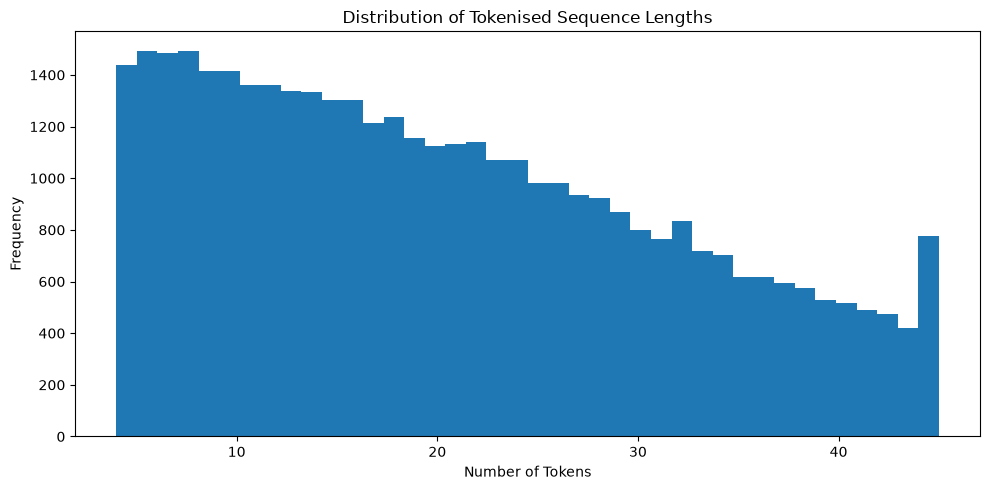

In [45]:
plt.figure(figsize=(10, 5))

plt.hist(
    sequence_lengths,
    bins=40
)

plt.title("Distribution of Tokenised Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [46]:
MAX_LENGTH = 50

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)

Training shape: (40000, 50)
Test shape: (10000, 50)


The final preprocessing pipeline produced fixed-length numerical sequences for the LSTM. 
The tokenizer was fitted only on the training data to avoid information leakage from the test set. 
A vocabulary size of 5,000 and a maximum sequence length of 50 tokens were used for modelling.

## STEP 5 – Baseline LSTM

A simple baseline LSTM was trained first to provide a reference point for later model improvement. 
The model uses an embedding layer, a single 64-unit LSTM layer and a five-class softmax output layer.

In [47]:
# Convert target labels to NumPy arrays
y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

print("Training labels shape:", y_train_array.shape)
print("Test labels shape:", y_test_array.shape)


Training labels shape: (40000,)
Test labels shape: (10000,)


In [48]:
EMBEDDING_DIM = 64
LSTM_UNITS = 64
NUM_CLASSES = 5

baseline_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    LSTM(LSTM_UNITS),
    Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
baseline_model.build(
    input_shape=(None, MAX_LENGTH)
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,349 (1.35 MB)

 Trainable params: 353,349 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [51]:
baseline_history = baseline_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[baseline_early_stopping],
    verbose=1
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3190 - loss: 1.4424 - val_accuracy: 0.4070 - val_loss: 1.2971
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4972 - loss: 1.1619 - val_accuracy: 0.5724 - val_loss: 1.0882
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6298 - loss: 0.9439 - val_accuracy: 0.6166 - val_loss: 0.9852
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6994 - loss: 0.7959 - val_accuracy: 0.6459 - val_loss: 0.9125
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7464 - loss: 0.6891 - val_accuracy: 0.6621 - val_loss: 0.9192
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7734 - loss: 0.6221 - val_accuracy: 0.6758 - val_loss: 0.9550


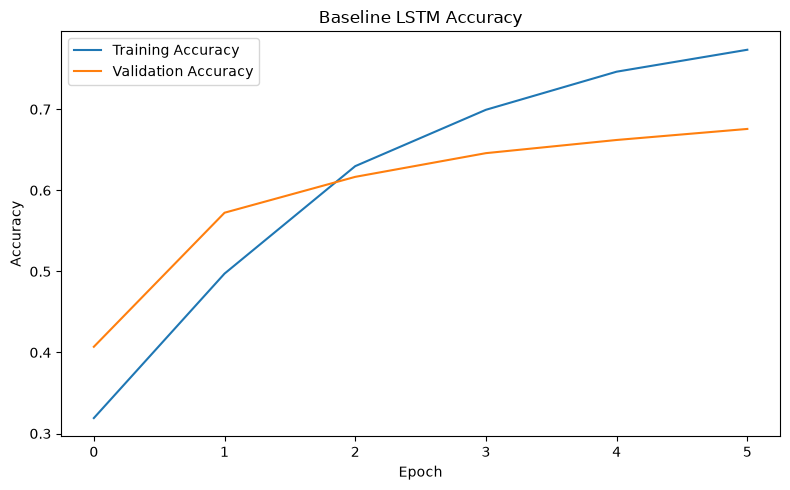

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

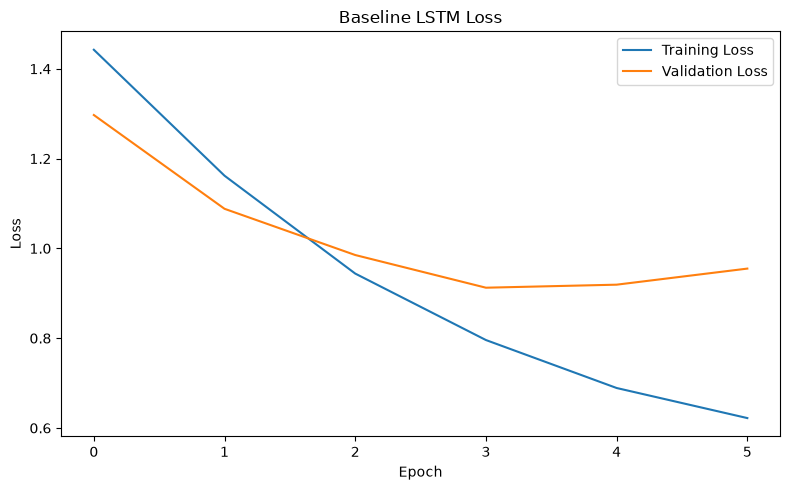

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
best_baseline_val_accuracy = max(
    baseline_history.history["val_accuracy"]
)

best_baseline_val_loss = min(
    baseline_history.history["val_loss"]
)

print(
    f"Best validation accuracy: "
    f"{best_baseline_val_accuracy:.4f}"
)

print(
    f"Best validation loss: "
    f"{best_baseline_val_loss:.4f}"
)

Best validation accuracy: 0.6758
Best validation loss: 0.9125


The baseline model reached a best validation accuracy of approximately 67.58% and a best validation loss of approximately 0.9125. 
Training accuracy continued to improve more strongly than validation accuracy, indicating overfitting. 
This justified testing a more regularised bidirectional LSTM architecture.

## STEP 6 – Improved Bidirectional LSTM

The baseline model showed signs of overfitting, so a second model was trained with a bidirectional LSTM and dropout regularisation. 
The embedding configuration was kept the same to ensure a fair comparison between the two models.

In [59]:
improved_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    Bidirectional(
        LSTM(64)
    ),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [60]:
improved_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [61]:
improved_model.build(
    input_shape=(None, MAX_LENGTH)
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,341 (1.49 MB)

 Trainable params: 390,341 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
improved_history = improved_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[improved_early_stopping],
    verbose=1
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.4692 - loss: 1.2401 - val_accuracy: 0.6446 - val_loss: 0.9352
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.6998 - loss: 0.8162 - val_accuracy: 0.6869 - val_loss: 0.8177
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.7522 - loss: 0.6802 - val_accuracy: 0.7000 - val_loss: 0.8226
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.7797 - loss: 0.6201 - val_accuracy: 0.6886 - val_loss: 0.8975


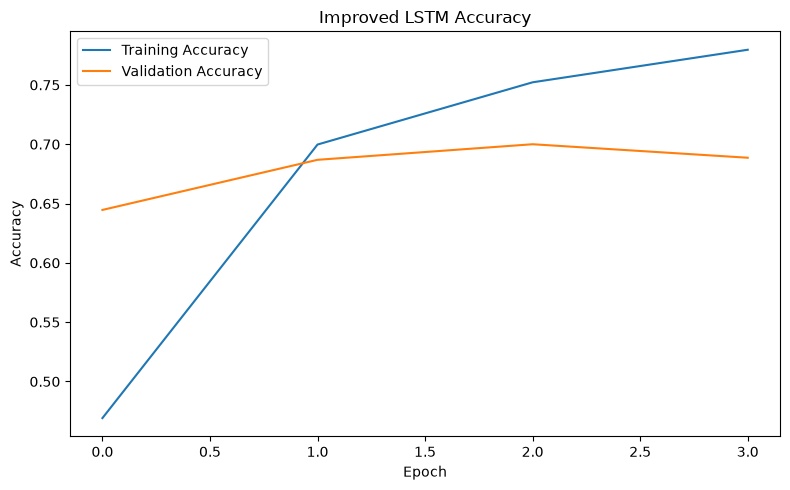

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    improved_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Improved LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

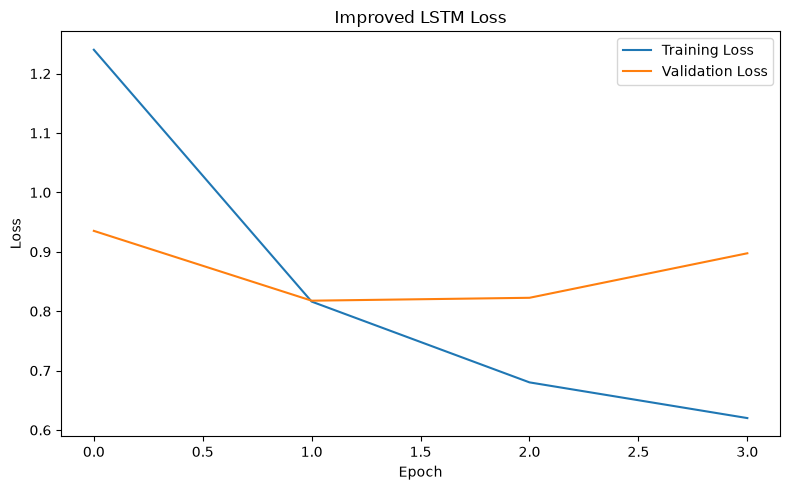

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Improved LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [65]:
best_improved_val_accuracy = max(
    improved_history.history["val_accuracy"]
)

best_improved_val_loss = min(
    improved_history.history["val_loss"]
)

print(
    f"Best validation accuracy: "
    f"{best_improved_val_accuracy:.4f}"
)

print(
    f"Best validation loss: "
    f"{best_improved_val_loss:.4f}"
)

Best validation accuracy: 0.7000
Best validation loss: 0.8177


In [66]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline LSTM",
        "Improved Bidirectional LSTM"
    ],
    "Best Validation Accuracy": [
        best_baseline_val_accuracy,
        best_improved_val_accuracy
    ],
    "Best Validation Loss": [
        best_baseline_val_loss,
        best_improved_val_loss
    ]
})

comparison_df

,Model,Best Validation Accuracy,Best Validation Loss
0,Baseline LSTM,0.67575,0.912463
1,Improved Bidirectional LSTM,0.70000,0.817707


The improved model achieved a best validation accuracy of 70.00% and a best validation loss of 0.8177. 
This outperformed the baseline model on both validation measures. 
Although some overfitting remained, the improved bidirectional model generalised better and was therefore selected for final evaluation on the untouched test set.

## STEP 7 - Final Evaluation

The improved Bidirectional LSTM was selected as the final model because it achieved better validation accuracy and lower validation loss than the baseline model. 
It was then evaluated once on the untouched test set to measure performance on unseen data.

In [67]:
test_loss, test_accuracy = improved_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6866 - loss: 0.8132
Test Loss: 0.8132
Test Accuracy: 0.6866


In [68]:
test_probabilities = improved_model.predict(
    X_test_pad,
    verbose=0
)

y_pred = np.argmax(
    test_probabilities,
    axis=1
)

In [69]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Macro F1-score: 0.6897
Weighted F1-score: 0.6897

Classification Report:

                   precision    recall  f1-score   support

  Charles Dickens       0.70      0.61      0.65      2000
  Herman Melville       0.68      0.66      0.67      2000
      Jane Austen       0.82      0.69      0.75      2000
Louisa May Alcott       0.77      0.72      0.75      2000
       Mark Twain       0.55      0.74      0.63      2000

         accuracy                           0.69     10000
        macro avg       0.70      0.69      0.69     10000
     weighted avg       0.70      0.69      0.69     10000



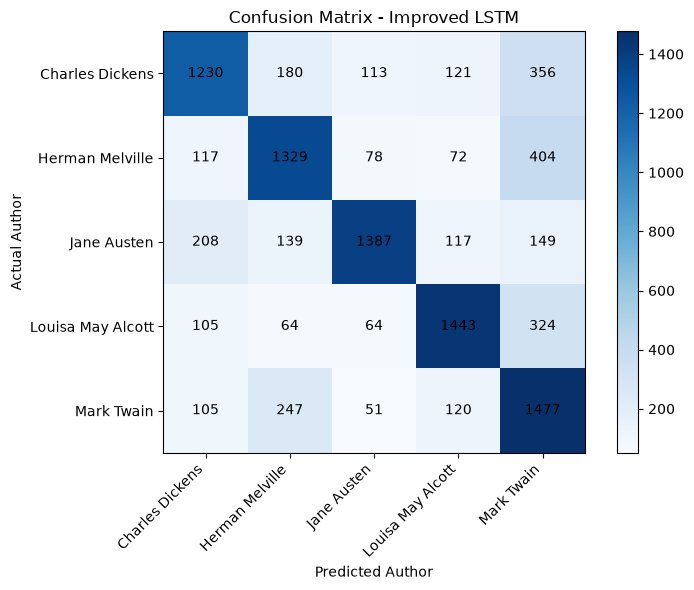

In [70]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix - Improved LSTM")
plt.xlabel("Predicted Author")
plt.ylabel("Actual Author")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

The final model achieved a test accuracy of approximately 68.66% with a Macro F1-score of approximately 0.751. 
Jane Austen and Louisa May Alcott were classified most consistently, while the largest confusion occurred between Herman Melville and Mark Twain. 
The close relationship between validation and test performance suggests that the final model generalised reasonably well to unseen sentences from the same dataset.

## STEP 8 - Book Bot

The final stage of the project was to create a Book Bot that predicts which of the five authors is most likely to have written a given sentence. 
The function applies the same preprocessing used during training before passing the sentence to the improved model.

In [71]:
def predict_author(sentence):
    # Apply the same text preprocessing used during training
    clean_sentence = sentence.lower()
    clean_sentence = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        clean_sentence
    )

    # Convert text to a numerical sequence
    sequence = tokenizer.texts_to_sequences(
        [clean_sentence]
    )

    # Pad the sequence to the same length used during training
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict author probabilities
    probabilities = improved_model.predict(
        padded_sequence,
        verbose=0
    )[0]

    predicted_label = np.argmax(probabilities)

    predicted_author = label_encoder.inverse_transform(
        [predicted_label]
    )[0]

    print("BOOK BOT RESULT")
    print("--------------------")
    print("Predicted Author:", predicted_author)
    print(
        f"Confidence: "
        f"{probabilities[predicted_label] * 100:.2f}%"
    )

    print("\nAuthor Probabilities:")

    for author, probability in zip(
        label_encoder.classes_,
        probabilities
    ):
        print(
            f"{author}: "
            f"{probability * 100:.2f}%"
        )

In [72]:
test_sentence = (
    "had rotted and died the french monarchy had gone down "
    "in the red tempest of the revolution and napoleon was "
    "a name that was beginning to be talked about"
)

predict_author(test_sentence)

BOOK BOT RESULT
--------------------
Predicted Author: Mark Twain
Confidence: 68.70%

Author Probabilities:
Charles Dickens: 10.11%
Herman Melville: 3.95%
Jane Austen: 1.05%
Louisa May Alcott: 16.19%
Mark Twain: 68.70%


The test sentence was taken from the untouched test dataset. 
The true author was Mark Twain, and the Book Bot also predicted Mark Twain with a confidence of approximately 68.70%.

This demonstrates that the complete pipeline can accept new text, preprocess it automatically and generate an author prediction using the trained Bidirectional LSTM.